In [1]:
# Cell 1 — setup
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import load_img, img_to_array

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

PROJECT_ROOT = Path("/teamspace/studios/this_studio/accessops_coco_ai")
CSV_PATH = PROJECT_ROOT / "artifacts" / "captions_clean_with_splits.csv"
PREPROC_CFG_PATH = PROJECT_ROOT / "artifacts" / "stage1c_preprocess" / "preprocess_config.json"
TOKENIZER_PATH = PROJECT_ROOT / "artifacts" / "stage1c_preprocess" / "tokenizer.json"

ART_DIR = PROJECT_ROOT / "artifacts" / "stage4"
MODEL_DIR = PROJECT_ROOT / "models" / "stage4_transfer"
ART_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

gpus = tf.config.list_physical_devices("GPU")
print("TF:", tf.__version__)
print("GPUs:", gpus)
assert len(gpus) > 0, "No GPU detected"

for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

assert CSV_PATH.exists()
assert PREPROC_CFG_PATH.exists()
assert TOKENIZER_PATH.exists()


2026-04-09 13:10:09.946173: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-09 13:10:10.284227: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-09 13:10:10.431910: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-09 13:10:10.432751: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-09 13:10:10.714474: I tensorflow/core/platform/cpu_feature_gua

TF: 2.16.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Cell 2 — tokenizer/config
cfg = json.loads(PREPROC_CFG_PATH.read_text(encoding="utf-8"))
MAX_LEN = int(cfg["sequence"]["max_length"])
VOCAB_SIZE = int(cfg["vocab"]["selected_vocab_size"])
SEQ_LEN = MAX_LEN - 1

tokenizer = tokenizer_from_json(TOKENIZER_PATH.read_text(encoding="utf-8"))
tokenizer.num_words = VOCAB_SIZE

start_id = tokenizer.word_index.get("<start>")
end_id = tokenizer.word_index.get("<end>")
assert start_id is not None and end_id is not None

print("MAX_LEN:", MAX_LEN, "SEQ_LEN:", SEQ_LEN, "VOCAB_SIZE:", VOCAB_SIZE)
print("start_id:", start_id, "end_id:", end_id)


MAX_LEN: 30 SEQ_LEN: 29 VOCAB_SIZE: 30000
start_id: 3 end_id: 4


In [3]:
# Cell 3 — load data + rebuild image paths
df = pd.read_csv(CSV_PATH)
df["comment_clean"] = df["comment_clean"].astype(str).str.strip().str.lower()
df["split"] = df["split"].astype(str).str.strip().str.lower()
df["image_name"] = df["image_name"].astype(str).str.strip()
df = df[df["comment_clean"].str.len() > 0].reset_index(drop=True)

train_candidates = [
    PROJECT_ROOT / "data" / "coco" / "train2017",
    PROJECT_ROOT / "artifacts" / "data" / "coco" / "train2017",
    PROJECT_ROOT / "data" / "coco" / "raw" / "train2017",
]
val_candidates = [
    PROJECT_ROOT / "data" / "coco" / "val2017",
    PROJECT_ROOT / "artifacts" / "data" / "coco" / "val2017",
    PROJECT_ROOT / "data" / "coco" / "raw" / "val2017",
]
TRAIN_IMG_DIR = next((p for p in train_candidates if p.exists()), train_candidates[0])
VAL_IMG_DIR = next((p for p in val_candidates if p.exists()), val_candidates[0])

df["image_path"] = np.where(
    df["split"].eq("train"),
    df["image_name"].map(lambda n: str(TRAIN_IMG_DIR / n)),
    df["image_name"].map(lambda n: str(VAL_IMG_DIR / n))
)

df = df[df["image_path"].map(lambda p: Path(p).exists())].reset_index(drop=True)

references_by_image = df.groupby("image_name")["comment_clean"].apply(list).to_dict()
image_path_by_name = df.groupby("image_name")["image_path"].first().to_dict()

print(df["split"].value_counts())
print(df.groupby("split")["image_name"].nunique())


split
train    591753
val       12508
test      12506
Name: count, dtype: int64
split
test       2500
train    118287
val        2500
Name: image_name, dtype: int64


In [4]:
# Cell 4 — sequences + splits (full data)
def wrap_caption(c):
    return f"<start> {c} <end>"

df["caption_wrapped"] = df["comment_clean"].map(wrap_caption)
seq = tokenizer.texts_to_sequences(df["caption_wrapped"].tolist())
seq = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post").astype(np.int32)
df["seq"] = list(seq)

def make_split(split_name):
    part = df[df["split"] == split_name].reset_index(drop=True)
    names = part["image_name"].astype(str).to_numpy()
    paths = part["image_path"].astype(str).to_numpy()
    seqm = np.stack(part["seq"].to_numpy())
    dec_in = seqm[:, :-1]
    y_out = seqm[:, 1:]
    return names, paths, dec_in, y_out

train_names, train_paths, train_dec_in, train_y = make_split("train")
val_names, val_paths, val_dec_in, val_y = make_split("val")
test_names, test_paths, test_dec_in, test_y = make_split("test")

split_sizes = {
    "train_caption_rows": int(len(train_names)),
    "val_caption_rows": int(len(val_names)),
    "test_caption_rows": int(len(test_names)),
    "train_unique_images": int(pd.Series(train_names).nunique()),
    "val_unique_images": int(pd.Series(val_names).nunique()),
    "test_unique_images": int(pd.Series(test_names).nunique()),
}
(ART_DIR / "selected_split_sizes.json").write_text(json.dumps(split_sizes, indent=2), encoding="utf-8")
print(json.dumps(split_sizes, indent=2))


{
  "train_caption_rows": 591753,
  "val_caption_rows": 12508,
  "test_caption_rows": 12506,
  "train_unique_images": 118287,
  "val_unique_images": 2500,
  "test_unique_images": 2500
}


In [5]:
# Cell 5 — tf.data
IMG_SIZE = 224
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

def load_example(path, dec_in, y):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return {"image_input": img, "text_input": dec_in}, y

def augment(inputs, y):
    img = inputs["image_input"]
    txt = inputs["text_input"]
    img = tf.image.random_flip_left_right(img)
    img = tf.clip_by_value(img + tf.random.uniform(tf.shape(img), -0.04, 0.04), -1.0, 1.0)
    return {"image_input": img, "text_input": txt}, y

def make_ds(paths, dec_in, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, dec_in, y))
    ds = ds.map(lambda p, d, t: load_example(p, tf.cast(d, tf.int32), tf.cast(t, tf.int32)),
                num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(min(len(paths), 50000), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_paths, train_dec_in, train_y, training=True)
val_ds = make_ds(val_paths, val_dec_in, val_y, training=False)
test_ds = make_ds(test_paths, test_dec_in, test_y, training=False)

print("Datasets ready")


2026-04-09 13:11:44.375631: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79187 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:00:05.0, compute capability: 8.0


Datasets ready


In [6]:
# Cell 6 — transfer model (frozen encoder first)f
tf.keras.backend.clear_session()

base_cnn = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
base_cnn.trainable = False

image_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
img_feat = base_cnn(image_input, training=False)
img_feat = layers.Dense(512, activation="relu")(img_feat)
img_feat = layers.Dropout(0.25)(img_feat)
img_feat = layers.Dense(384, activation="relu")(img_feat)

text_input = layers.Input(shape=(SEQ_LEN,), dtype="int32", name="text_input")
emb = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=384, mask_zero=False)(text_input)
dec = layers.LSTM(512, return_sequences=True, dropout=0.30)(emb)

img_rep = layers.Lambda(lambda t: tf.tile(tf.expand_dims(t, axis=1), [1, SEQ_LEN, 1]))(img_feat)
x = layers.Concatenate(axis=-1)([dec, img_rep])
x = layers.TimeDistributed(layers.Dense(512, activation="relu"))(x)
x = layers.Dropout(0.30)(x)
out = layers.TimeDistributed(layers.Dense(VOCAB_SIZE, activation="softmax", dtype="float32"))(x)

model = models.Model(inputs=[image_input, text_input], outputs=out)

scce = tf.keras.losses.SparseCategoricalCrossentropy(reduction="none")

def masked_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    loss = scce(y_true, y_pred)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    return tf.reduce_sum(loss * mask) / (tf.reduce_sum(mask) + 1e-8)

def masked_accuracy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    pred_ids = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
    match = tf.cast(tf.equal(y_true, pred_ids), tf.float32)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    return tf.reduce_sum(match * mask) / (tf.reduce_sum(mask) + 1e-8)

model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss=masked_loss,
    metrics=[masked_accuracy],
    jit_compile=False,
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 1280)      │  2,257,984 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    655,872 │ mobilenetv2_1.00… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (None, 29)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 29, 384)   │ 11,520,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 384)       │    196,992 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 29, 512)   │  1,837,056 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 29, 384)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 29, 896)   │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 29, 512)   │    459,264 │ concatenate[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 29, 512)   │          0 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 29, 30000) │ 15,390,000 │ dropout_1[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,317,168 (123.28 MB)

 Trainable params: 30,059,184 (114.67 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
# Cell 6b - load trained Stage 4 weights (no retraining)
ckpt = MODEL_DIR / "best_stage4_finetune.keras"
assert ckpt.exists(), f"Missing checkpoint: {ckpt}"
model.load_weights(ckpt, skip_mismatch=False)
print("Loaded:", ckpt)

Loaded: /teamspace/studios/this_studio/accessops_coco_ai/models/stage4_transfer/best_stage4_finetune.keras


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 52 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [7]:
# Cell 7 — Phase 1 (frozen encoder)
ckpt_frozen = MODEL_DIR / "best_stage4_frozen.keras"
cb1 = [
    callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, verbose=1),
    callbacks.ModelCheckpoint(filepath=str(ckpt_frozen), monitor="val_loss", save_best_only=True),
    callbacks.TerminateOnNaN(),
]

history_frozen = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=cb1,
    verbose=1,
)


Epoch 1/8


2026-04-07 10:48:14.329549: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 16480 of 50000
2026-04-07 10:48:34.328446: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 47214 of 50000
2026-04-07 10:48:36.679834: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
2026-04-07 10:48:37.002414: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


9247/9247 ━━━━━━━━━━━━━━━━━━━━ 679s 69ms/step - loss: 2.9862 - masked_accuracy: 0.4372 - val_loss: 2.7577 - val_masked_accuracy: 0.4582 - learning_rate: 0.0010
Epoch 2/8


2026-04-07 10:59:23.973780: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 17825 of 50000


   2/9247 ━━━━━━━━━━━━━━━━━━━━ 12:26 81ms/step - loss: 3.2428 - masked_accuracy: 0.4156  

...

9247/9247 ━━━━━━━━━━━━━━━━━━━━ 657s 68ms/step - loss: 2.3972 - masked_accuracy: 0.4961 - val_loss: 2.5200 - val_masked_accuracy: 0.4919 - learning_rate: 5.0000e-04
Epoch 8/8


2026-04-07 12:05:05.249343: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 17446 of 50000


   1/9247 ━━━━━━━━━━━━━━━━━━━━ 73:13:22 29s/step - loss: 2.6241 - masked_accuracy: 0.4443

2026-04-07 12:05:23.598932: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


9247/9247 ━━━━━━━━━━━━━━━━━━━━ 662s 69ms/step - loss: 2.3688 - masked_accuracy: 0.4993 - val_loss: 2.5119 - val_masked_accuracy: 0.4927 - learning_rate: 5.0000e-04


In [8]:
# Cell 8 — Phase 2 (fine-tune top encoder layers)
base_cnn.trainable = True
for layer in base_cnn.layers[:-40]:
    layer.trainable = False
for layer in base_cnn.layers[-40:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss=masked_loss,
    metrics=[masked_accuracy],
    jit_compile=False,
)

ckpt_finetune = MODEL_DIR / "best_stage4_finetune.keras"
cb2 = [
    callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, verbose=1),
    callbacks.ModelCheckpoint(filepath=str(ckpt_finetune), monitor="val_loss", save_best_only=True),
]

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    callbacks=cb2,
    verbose=1,
)


Epoch 1/6


2026-04-07 12:18:06.043748: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 17953 of 50000
2026-04-07 12:18:24.123064: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


9247/9247 ━━━━━━━━━━━━━━━━━━━━ 728s 74ms/step - loss: 2.3522 - masked_accuracy: 0.5011 - val_loss: 2.4959 - val_masked_accuracy: 0.4959 - learning_rate: 1.0000e-04
Epoch 2/6


2026-04-07 12:30:03.820958: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 17885 of 50000


   1/9247 ━━━━━━━━━━━━━━━━━━━━ 72:53:31 28s/step - loss: 2.5003 - masked_accuracy: 0.4643

...

9246/9247 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 2.2985 - masked_accuracy: 0.5072
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
9247/9247 ━━━━━━━━━━━━━━━━━━━━ 712s 74ms/step - loss: 2.2676 - masked_accuracy: 0.5124 - val_loss: 2.4458 - val_masked_accuracy: 0.5034 - learning_rate: 1.0000e-04
Epoch 6/6


2026-04-07 13:17:37.006481: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 20595 of 50000


   1/9247 ━━━━━━━━━━━━━━━━━━━━ 64:09:53 25s/step - loss: 2.3147 - masked_accuracy: 0.4941

2026-04-07 13:17:51.840004: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


9247/9247 ━━━━━━━━━━━━━━━━━━━━ 711s 74ms/step - loss: 2.2442 - masked_accuracy: 0.5155 - val_loss: 2.4263 - val_masked_accuracy: 0.5066 - learning_rate: 5.0000e-05


In [9]:
# Cell 9 — BLEU eval on full test unique images
index_word = {idx: w for w, idx in tokenizer.word_index.items() if idx < VOCAB_SIZE}
index_word[0] = "<pad>"

def load_image_for_infer(image_path):
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = img_to_array(img).astype("float32")
    arr = tf.keras.applications.mobilenet_v2.preprocess_input(arr)
    return np.expand_dims(arr, axis=0)

def generate_caption(image_path, max_steps=SEQ_LEN):
    img = load_image_for_infer(image_path)
    tokens = [start_id]

    for _ in range(max_steps):
        dec_in = np.zeros((1, SEQ_LEN), dtype=np.int32)
        use = tokens[:SEQ_LEN]
        dec_in[0, :len(use)] = use

        pred = model({"image_input": img, "text_input": dec_in}, training=False).numpy()[0]
        pos = min(len(use) - 1, SEQ_LEN - 1)
        nxt = int(np.argmax(pred[pos]))

        if nxt == 0 or nxt == end_id:
            break
        tokens.append(nxt)

    words = []
    for tid in tokens[1:]:
        w = index_word.get(tid, "<unk>")
        if w not in {"<pad>", "<start>", "<end>", "<unk>"}:
            words.append(w)
    return " ".join(words).strip() if words else "a person in a scene"

test_unique = sorted(set(test_names.tolist()))
sf = SmoothingFunction().method1

bleu1_scores, bleu2_scores, bleu3_scores, bleu4_scores = [], [], [], []
sample_rows = []

for n in tqdm(test_unique, desc="Stage4 BLEU eval"):
    pred = generate_caption(image_path_by_name[n])
    pred_toks = pred.split()
    refs = [c.split() for c in references_by_image.get(n, []) if isinstance(c, str) and c.strip()]
    if refs:
        bleu1_scores.append(sentence_bleu(refs, pred_toks, weights=(1,0,0,0), smoothing_function=sf))
        bleu2_scores.append(sentence_bleu(refs, pred_toks, weights=(0.5,0.5,0,0), smoothing_function=sf))
        bleu3_scores.append(sentence_bleu(refs, pred_toks, weights=(1/3,1/3,1/3,0), smoothing_function=sf))
        bleu4_scores.append(sentence_bleu(refs, pred_toks, weights=(0.25,0.25,0.25,0.25), smoothing_function=sf))

for n in test_unique[:30]:
    sample_rows.append({
        "image_name": n,
        "generated_caption": generate_caption(image_path_by_name[n]),
        "reference_caption_1": references_by_image.get(n, [""])[0]
    })

bleu1 = float(np.mean(bleu1_scores)) if bleu1_scores else 0.0
bleu2 = float(np.mean(bleu2_scores)) if bleu2_scores else 0.0
bleu3 = float(np.mean(bleu3_scores)) if bleu3_scores else 0.0
bleu4 = float(np.mean(bleu4_scores)) if bleu4_scores else 0.0

print("BLEU-1:", round(bleu1, 4))
print("BLEU-2:", round(bleu2, 4))
print("BLEU-3:", round(bleu3, 4))
print("BLEU-4:", round(bleu4, 4))


Stage4 BLEU eval:   0%|          | 0/2500 [00:00<?, ?it/s]

2026-04-08 15:26:58.915321: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


KeyboardInterrupt: 

In [8]:
# Cell 9 (LITE) - helpers only, no full evaluation run
index_word = {idx: w for w, idx in tokenizer.word_index.items() if idx < VOCAB_SIZE}
index_word[0] = "<pad>"

def load_image_for_infer(image_path):
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = img_to_array(img).astype("float32")
    arr = tf.keras.applications.mobilenet_v2.preprocess_input(arr)
    return np.expand_dims(arr, axis=0)

def decode_greedy(model, image_path, max_steps=SEQ_LEN):
    img = load_image_for_infer(image_path)
    tokens = [start_id]
    for _ in range(max_steps):
        dec_in = np.zeros((1, SEQ_LEN), dtype=np.int32)
        use = tokens[:SEQ_LEN]
        dec_in[0, :len(use)] = use
        pred = model({"image_input": img, "text_input": dec_in}, training=False).numpy()[0]
        pos = min(len(use) - 1, SEQ_LEN - 1)
        nxt = int(np.argmax(pred[pos]))
        if nxt == 0 or nxt == end_id:
            break
        tokens.append(nxt)

    words = []
    for tid in tokens[1:]:
        w = index_word.get(tid, "<unk>")
        if w not in {"<pad>", "<start>", "<end>", "<unk>"}:
            words.append(w)
    return " ".join(words).strip() if words else "a person in a scene"

def evaluate_bleu(model, eval_names, references_by_image):
    sf = SmoothingFunction().method1
    b1, b4 = [], []
    for n in tqdm(eval_names, desc="BLEU eval"):
        pred = decode_greedy(model, image_paths[n])
        refs = [r.split() for r in references_by_image.get(n, []) if isinstance(r, str) and r.strip()]
        if refs:
            pt = pred.split()
            b1.append(sentence_bleu(refs, pt, weights=(1, 0, 0, 0), smoothing_function=sf))
            b4.append(sentence_bleu(refs, pt, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=sf))
    return {"bleu1": float(np.mean(b1) if b1 else 0.0), "bleu4": float(np.mean(b4) if b4 else 0.0)}

test_unique = sorted(pd.Series(test_names).astype(str).unique().tolist())
EVAL_NAMES_FAST = test_unique[:300]   # for B2 search
EVAL_NAMES_FULL = test_unique          # for final winner only
print("FAST:", len(EVAL_NAMES_FAST), "FULL:", len(EVAL_NAMES_FULL))


FAST: 300 FULL: 2500


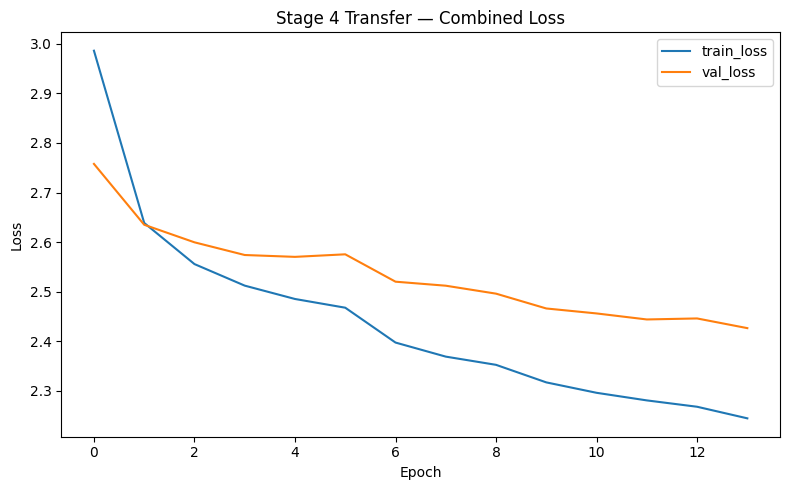

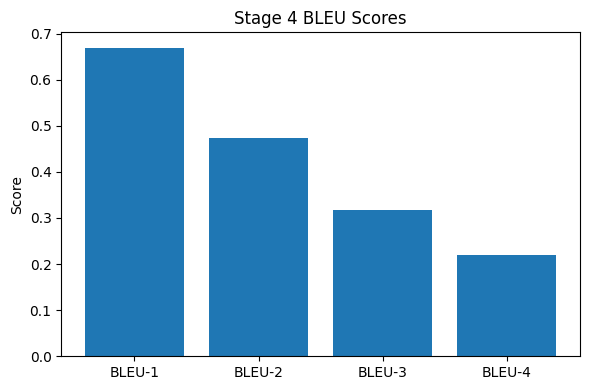

{
  "val_loss_best_frozen": 2.511911392211914,
  "val_loss_best_finetune": 2.4262704849243164,
  "val_masked_accuracy_best_finetune": 0.5065993666648865,
  "test_bleu1": 0.6693386813373521,
  "test_bleu2": 0.4729898883543001,
  "test_bleu3": 0.3171899623822222,
  "test_bleu4": 0.21930927466149114,
  "eval_images_count": 2500,
  "vocab_size": 30000,
  "max_len": 30,
  "img_size": 224
}


In [10]:
# Cell 10 — save artifacts, metrics table, charts
hist_frozen_df = pd.DataFrame(history_frozen.history); hist_frozen_df["phase"] = "frozen"
hist_ft_df = pd.DataFrame(history_finetune.history);   hist_ft_df["phase"] = "finetune"
hist_all = pd.concat([hist_frozen_df, hist_ft_df], ignore_index=True)
hist_all.to_csv(ART_DIR / "training_history_combined.csv", index=False)

plt.figure(figsize=(8,5))
plt.plot(hist_all["loss"].values, label="train_loss")
plt.plot(hist_all["val_loss"].values, label="val_loss")
plt.title("Stage 4 Transfer — Combined Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(ART_DIR / "training_curve_loss.png", dpi=180)
plt.show()

plt.figure(figsize=(6,4))
plt.bar(["BLEU-1","BLEU-2","BLEU-3","BLEU-4"], [bleu1, bleu2, bleu3, bleu4])
plt.title("Stage 4 BLEU Scores")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig(ART_DIR / "bleu_scores.png", dpi=180)
plt.show()

pd.DataFrame(sample_rows).to_csv(ART_DIR / "sample_caption_predictions.csv", index=False)
(ART_DIR / "tokenizer.json").write_text(tokenizer.to_json(), encoding="utf-8")

metrics = {
    "val_loss_best_frozen": float(np.min(hist_frozen_df["val_loss"])),
    "val_loss_best_finetune": float(np.min(hist_ft_df["val_loss"])),
    "val_masked_accuracy_best_finetune": float(np.max(hist_ft_df["val_masked_accuracy"])),
    "test_bleu1": bleu1,
    "test_bleu2": bleu2,
    "test_bleu3": bleu3,
    "test_bleu4": bleu4,
    "eval_images_count": int(len(test_unique)),
    "vocab_size": int(VOCAB_SIZE),
    "max_len": int(MAX_LEN),
    "img_size": int(IMG_SIZE)
}
(ART_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

metrics_table = pd.DataFrame([
    {"metric": "val_loss_best_frozen", "value": metrics["val_loss_best_frozen"]},
    {"metric": "val_loss_best_finetune", "value": metrics["val_loss_best_finetune"]},
    {"metric": "val_masked_accuracy_best_finetune", "value": metrics["val_masked_accuracy_best_finetune"]},
    {"metric": "test_bleu1", "value": metrics["test_bleu1"]},
    {"metric": "test_bleu2", "value": metrics["test_bleu2"]},
    {"metric": "test_bleu3", "value": metrics["test_bleu3"]},
    {"metric": "test_bleu4", "value": metrics["test_bleu4"]},
])
metrics_table.to_csv(ART_DIR / "metrics_table.csv", index=False)

model.save(MODEL_DIR / "stage4_transfer_final.keras")
print(json.dumps(metrics, indent=2))


In [11]:
# Cell 11 — comparison vs Stage 3
stage3_metrics_path = PROJECT_ROOT / "artifacts" / "stage3" / "metrics.json"
if stage3_metrics_path.exists():
    m3 = json.loads(stage3_metrics_path.read_text(encoding="utf-8"))
    comp = pd.DataFrame([
        {"stage": "Stage 3 scratch", "bleu1": m3.get("test_bleu1"), "bleu4": m3.get("test_bleu4")},
        {"stage": "Stage 4 transfer", "bleu1": metrics["test_bleu1"], "bleu4": metrics["test_bleu4"]},
    ])
    comp["delta_bleu1_vs_stage3"] = comp["bleu1"] - float(m3.get("test_bleu1", 0.0))
    comp["delta_bleu4_vs_stage3"] = comp["bleu4"] - float(m3.get("test_bleu4", 0.0))
    comp.to_csv(ART_DIR / "stage3_vs_stage4_comparison.csv", index=False)
    display(comp)
    print("Saved:", ART_DIR / "stage3_vs_stage4_comparison.csv")


,stage,bleu1,bleu4,delta_bleu1_vs_stage3,delta_bleu4_vs_stage3
0,Stage 3 scratch,0.598141,0.168521,0.000000,0.000000
1,Stage 4 transfer,0.669339,0.219309,0.071197,0.050788


Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage4/stage3_vs_stage4_comparison.csv


In [12]:
# Cell 12 — gate
required = [
    ART_DIR / "selected_split_sizes.json",
    ART_DIR / "training_history_combined.csv",
    ART_DIR / "training_curve_loss.png",
    ART_DIR / "bleu_scores.png",
    ART_DIR / "sample_caption_predictions.csv",
    ART_DIR / "metrics.json",
    ART_DIR / "metrics_table.csv",
    ART_DIR / "tokenizer.json",
    MODEL_DIR / "best_stage4_frozen.keras",
    MODEL_DIR / "best_stage4_finetune.keras",
    MODEL_DIR / "stage4_transfer_final.keras",
]
for p in required:
    assert p.exists(), f"Missing: {p}"

m = json.loads((ART_DIR / "metrics.json").read_text(encoding="utf-8"))
assert not np.isnan(m["test_bleu1"]) and not np.isnan(m["test_bleu4"])

print("STAGE 4 PASS")
print("BLEU-1:", round(m["test_bleu1"], 4), "| BLEU-4:", round(m["test_bleu4"], 4))


STAGE 4 PASS
BLEU-1: 0.6693 | BLEU-4: 0.2193


optimisation

In [ ]:
# ===== Stage 5 - Cell A: B0 lock (from Stage 4 metrics) =====
import json, numpy as np, pandas as pd
from pathlib import Path

STAGE5_ART = PROJECT_ROOT / "artifacts" / "stage5"
STAGE5_MODELS = PROJECT_ROOT / "models" / "stage5_opt"
STAGE5_ART.mkdir(parents=True, exist_ok=True)
STAGE5_MODELS.mkdir(parents=True, exist_ok=True)

MODEL_FINAL = MODEL_DIR / "best_stage4_finetune.keras"
assert MODEL_FINAL.exists(), f"Missing: {MODEL_FINAL}"

m4_path = PROJECT_ROOT / "artifacts" / "stage4" / "metrics.json"
assert m4_path.exists(), f"Missing: {m4_path}"
m4 = json.loads(m4_path.read_text(encoding="utf-8"))

results = [{
    "run_id": "B0_baseline_stage4A_metrics",
    "train_change": "none",
    "decode_change": "greedy",
    "optimizer": None,
    "lr": None,
    "epochs": 0,
    "val_loss_best": float(m4.get("val_loss_best_finetune", np.nan)),
    "bleu1_fast": float(m4.get("test_bleu1", np.nan)),
    "bleu4_fast": float(m4.get("test_bleu4", np.nan)),
    "notes": "Locked from stage4 metrics.json"
}]

progress_df = pd.DataFrame(results)
progress_path = STAGE5_ART / "stage4b_results_progress.csv"
progress_df.to_csv(progress_path, index=False)
display(progress_df)
print("Saved:", progress_path)


,run_id,train_change,decode_change,optimizer,lr,epochs,val_loss_best,bleu1_fast,bleu4_fast,notes
0,B0_baseline_stage4A_metrics,none,greedy,None,None,0,2.42627,0.669339,0.219309,Locked from stage4 metrics.json


Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage5/stage4b_results_progress.csv


In [10]:
# ===== Stage 5 - Cell B: B2 optimisation runs (optimizer/LR) =====
import tensorflow as tf
import pandas as pd
import numpy as np

# Ensure Phase-2-style trainability (top layers unfrozen, BN frozen)
def set_phase2_trainable(model, unfreeze_top_n=40):
    base = None
    for lyr in model.layers:
        if isinstance(lyr, tf.keras.Model) and "mobilenet" in lyr.name.lower():
            base = lyr
            break
    if base is None:
        print("Warning: MobileNet base not found; keeping current trainable setup.")
        return

    base.trainable = True
    for lyr in base.layers[:-unfreeze_top_n]:
        lyr.trainable = False
    for lyr in base.layers[-unfreeze_top_n:]:
        if isinstance(lyr, tf.keras.layers.BatchNormalization):
            lyr.trainable = False
        else:
            lyr.trainable = True

def make_optimizer(name, lr):
    if name.lower() == "adamw":
        return tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4)
    return tf.keras.optimizers.Adam(learning_rate=lr)

b2_grid = [
    {"run_id": "B2_adam_1e4",   "optimizer": "adam",  "lr": 1e-4, "epochs": 3},
    {"run_id": "B2_adamw_8e5",  "optimizer": "adamw", "lr": 8e-5, "epochs": 3},
]

for cfg in b2_grid:
    tf.keras.backend.clear_session()

    # rebuild from your existing builder in this notebook
    # (Cell 6 already defines model building code; reuse that by re-running Cell 6 if needed)
    # here we assume `model` already exists; if not, run Cell 6 first.
    if "model" not in globals():
        raise RuntimeError("`model` not found. Run Cell 6 first.")

    model.load_weights(str(MODEL_FINAL), skip_mismatch=False)
    set_phase2_trainable(model, unfreeze_top_n=40)

    opt = make_optimizer(cfg["optimizer"], cfg["lr"])
    model.compile(optimizer=opt, loss=masked_loss, metrics=[masked_accuracy], jit_compile=False)

    ckpt = STAGE5_MODELS / f"{cfg['run_id']}.keras"
    cb = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(filepath=str(ckpt), monitor="val_loss", save_best_only=True),
    ]

    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=cfg["epochs"],
        callbacks=cb,
        verbose=1
    )

    fast = evaluate_bleu(model, EVAL_NAMES_FAST, references_by_image)

    results.append({
        "run_id": cfg["run_id"],
        "train_change": "optimizer_lr_tuning",
        "decode_change": "greedy",
        "optimizer": cfg["optimizer"],
        "lr": cfg["lr"],
        "epochs": cfg["epochs"],
        "val_loss_best": float(np.min(hist.history["val_loss"])),
        "bleu1_fast": float(fast["bleu1"]),
        "bleu4_fast": float(fast["bleu4"]),
        "notes": f"ckpt={ckpt.name}"
    })

    pd.DataFrame(results).to_csv(STAGE5_ART / "stage4b_results_progress.csv", index=False)

display(pd.DataFrame(results))
print("Saved:", STAGE5_ART / "stage4b_results_progress.csv")


Epoch 1/3


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 52 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-04-08 15:42:23.991687: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 14628 of 50000
2026-04-08 15:42:43.991683: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 43163 of 50000
2026-04-08 15:42:49.709949: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
2026-04-08 15:42:50.023888: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


9247/9247 ━━━━━━━━━━━━━━━━━━━━ 742s 74ms/step - loss: 2.2416 - masked_accuracy: 0.5158 - val_loss: 2.4380 - val_masked_accuracy: 0.5051 - learning_rate: 1.0000e-04
Epoch 2/3


2026-04-08 15:54:31.365323: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 17797 of 50000


   1/9247 ━━━━━━━━━━━━━━━━━━━━ 73:03:58 28s/step - loss: 2.5787 - masked_accuracy: 0.4809

2026-04-08 15:54:49.648634: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


9246/9247 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 2.2554 - masked_accuracy: 0.5127
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
9247/9247 ━━━━━━━━━━━━━━━━━━━━ 711s 74ms/step - loss: 2.2281 - masked_accuracy: 0.5174 - val_loss: 2.4384 - val_masked_accuracy: 0.5052 - learning_rate: 1.0000e-04


BLEU eval:   0%|          | 0/300 [00:00<?, ?it/s]

NameError: name 'image_paths' is not defined

In [11]:
# Fix missing image path dict
if "image_paths" not in globals():
    if "image_path_by_name" in globals():
        image_paths = {str(k): str(v) for k, v in image_path_by_name.items()}
    elif "df" in globals():
        image_paths = (
            df.drop_duplicates("image_name")
              .assign(image_name=lambda x: x["image_name"].astype(str))
              .set_index("image_name")["image_path"]
              .astype(str)
              .to_dict()
        )
    else:
        raise RuntimeError("No source found for image_paths")

EVAL_NAMES_FAST = [str(x) for x in EVAL_NAMES_FAST]
print("image_paths:", len(image_paths), "EVAL_NAMES_FAST:", len(EVAL_NAMES_FAST))


image_paths: 123287 EVAL_NAMES_FAST: 300


In [13]:
# Resume after crash (uses current model/cfg/hist already in memory)
fast = evaluate_bleu(model, EVAL_NAMES_FAST, references_by_image)

results.append({
    "run_id": cfg["run_id"],
    "train_change": "optimizer_lr_tuning",
    "decode_change": "greedy",
    "optimizer": cfg["optimizer"],
    "lr": cfg["lr"],
    "epochs": cfg["epochs"],
    "val_loss_best": float(np.min(hist.history["val_loss"])),
    "bleu1_fast": float(fast["bleu1"]),
    "bleu4_fast": float(fast["bleu4"]),
    "notes": f"ckpt={ckpt.name}"
})

pd.DataFrame(results).to_csv(STAGE5_ART / "stage4b_results_progress.csv", index=False)
display(pd.DataFrame(results))
print("Saved:", STAGE5_ART / "stage4b_results_progress.csv")


BLEU eval:   0%|          | 0/300 [00:00<?, ?it/s]

,run_id,train_change,decode_change,optimizer,lr,epochs,val_loss_best,bleu1_fast,bleu4_fast,notes
0,B0_baseline_stage4A_metrics,none,greedy,NaN,NaN,0,2.426270,0.669339,0.219309,Locked from stage4 metrics.json
1,B2_adam_1e4,optimizer_lr_tuning,greedy,adam,0.0001,3,2.437979,0.664631,0.225367,ckpt=B2_adam_1e4.keras


Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage5/stage4b_results_progress.csv


In [14]:
import pandas as pd
p = "/teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage5/stage4b_results_progress.csv"
df = pd.read_csv(p)
print(df["run_id"].tolist())
display(df[["run_id","bleu1_fast","bleu4_fast","val_loss_best"]])


['B0_baseline_stage4A_metrics', 'B2_adam_1e4']


,run_id,bleu1_fast,bleu4_fast,val_loss_best
0,B0_baseline_stage4A_metrics,0.669339,0.219309,2.426270
1,B2_adam_1e4,0.664631,0.225367,2.437979


In [10]:
# Helper defs for B2
import tensorflow as tf

def make_opt(name, lr):
    name = str(name).lower()
    if name == "adamw":
        return tf.keras.optimizers.AdamW(learning_rate=float(lr), weight_decay=1e-4)
    if name == "adam":
        return tf.keras.optimizers.Adam(learning_rate=float(lr))
    raise ValueError(f"Unsupported optimizer: {name}")

def set_phase2_trainable(model, unfreeze_top_n=40):
    base = None
    for lyr in model.layers:
        if isinstance(lyr, tf.keras.Model) and "mobilenet" in lyr.name.lower():
            base = lyr
            break
    if base is None:
        print("Warning: MobileNet base not found; leaving trainable flags unchanged.")
        return

    base.trainable = True
    for lyr in base.layers[:-unfreeze_top_n]:
        lyr.trainable = False
    for lyr in base.layers[-unfreeze_top_n:]:
        if isinstance(lyr, tf.keras.layers.BatchNormalization):
            lyr.trainable = False
        else:
            lyr.trainable = True

print("Helpers ready: make_opt, set_phase2_trainable")


Helpers ready: make_opt, set_phase2_trainable


In [17]:
import pandas as pd
import numpy as np
import tensorflow as tf

progress_path = STAGE5_ART / "stage4b_results_progress.csv"
res_df = pd.read_csv(progress_path)

b2_grid_all = [
    {"run_id": "B2_adam_1e4",  "optimizer": "adam",  "lr": 1e-4, "epochs": 3},
    {"run_id": "B2_adamw_8e5", "optimizer": "adamw", "lr": 8e-5, "epochs": 3},
    {"run_id": "B2_adamw_5e5", "optimizer": "adamw", "lr": 5e-5, "epochs": 3},
]

done = set(res_df["run_id"].astype(str).tolist())
todo = [c for c in b2_grid_all if c["run_id"] not in done]
print("Remaining:", [c["run_id"] for c in todo])

for cfg in todo:
    model.load_weights(str(MODEL_FINAL), skip_mismatch=False)
    set_phase2_trainable(model, unfreeze_top_n=40)
    model.compile(
        optimizer=make_opt(cfg["optimizer"], cfg["lr"]),
        loss=masked_loss,
        metrics=[masked_accuracy],
        jit_compile=False
    )

    ckpt = STAGE5_MODELS / f"{cfg['run_id']}.keras"
    cb = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(filepath=str(ckpt), monitor="val_loss", save_best_only=True),
    ]

    hist = model.fit(train_ds, validation_data=val_ds, epochs=cfg["epochs"], callbacks=cb, verbose=1)
    fast = evaluate_bleu(model, EVAL_NAMES_FAST, references_by_image)

    row = {
        "run_id": cfg["run_id"],
        "train_change": "optimizer_lr_tuning",
        "decode_change": "greedy",
        "optimizer": cfg["optimizer"],
        "lr": cfg["lr"],
        "epochs": cfg["epochs"],
        "val_loss_best": float(np.min(hist.history["val_loss"])),
        "bleu1_fast": float(fast["bleu1"]),
        "bleu4_fast": float(fast["bleu4"]),
        "notes": f"ckpt={ckpt.name}",
    }

    res_df = res_df[res_df["run_id"] != cfg["run_id"]]
    res_df = pd.concat([res_df, pd.DataFrame([row])], ignore_index=True)
    res_df.to_csv(progress_path, index=False)
    display(res_df.sort_values(["bleu4_fast", "bleu1_fast"], ascending=False))

print("Saved:", progress_path)


Remaining: ['B2_adamw_8e5', 'B2_adamw_5e5']
Epoch 1/3


2026-04-08 16:45:46.151717: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 17929 of 50000


   1/9247 ━━━━━━━━━━━━━━━━━━━━ 100:25:47 39s/step - loss: 2.3196 - masked_accuracy: 0.5049

2026-04-08 16:46:04.392383: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


9247/9247 ━━━━━━━━━━━━━━━━━━━━ 742s 76ms/step - loss: 2.2349 - masked_accuracy: 0.5165 - val_loss: 2.4331 - val_masked_accuracy: 0.5056 - learning_rate: 8.0000e-05
Epoch 2/3


...

2026-04-08 18:00:14.327143: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


9247/9247 ━━━━━━━━━━━━━━━━━━━━ 726s 75ms/step - loss: 2.2085 - masked_accuracy: 0.5201 - val_loss: 2.4218 - val_masked_accuracy: 0.5071 - learning_rate: 5.0000e-05


BLEU eval:   0%|          | 0/300 [00:00<?, ?it/s]

,run_id,train_change,decode_change,optimizer,lr,epochs,val_loss_best,bleu1_fast,bleu4_fast,notes
3,B2_adamw_5e5,optimizer_lr_tuning,greedy,adamw,0.00005,3,2.421805,0.670782,0.230983,ckpt=B2_adamw_5e5.keras
1,B2_adam_1e4,optimizer_lr_tuning,greedy,adam,0.00010,3,2.437979,0.664631,0.225367,ckpt=B2_adam_1e4.keras
2,B2_adamw_8e5,optimizer_lr_tuning,greedy,adamw,0.00008,3,2.428496,0.666582,0.223830,ckpt=B2_adamw_8e5.keras
0,B0_baseline_stage4A_metrics,none,greedy,NaN,NaN,0,2.426270,0.669339,0.219309,Locked from stage4 metrics.json


Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage5/stage4b_results_progress.csv


In [18]:
# B2 winner (from FAST) + FULL eval lock
import pandas as pd

progress_path = STAGE5_ART / "stage4b_results_progress.csv"
res_df = pd.read_csv(progress_path)

b2 = res_df[res_df["run_id"].astype(str).str.startswith("B2_")].copy()
assert len(b2) > 0, "No B2 rows found."

best = b2.sort_values(
    ["bleu4_fast", "bleu1_fast", "val_loss_best"],
    ascending=[False, False, True]
).iloc[0]

best_run = best["run_id"]
best_ckpt = STAGE5_MODELS / f"{best_run}.keras"
assert best_ckpt.exists(), f"Missing checkpoint: {best_ckpt}"

if "EVAL_NAMES_FULL" not in globals():
    EVAL_NAMES_FULL = sorted(pd.Series(test_names).astype(str).unique().tolist())

model.load_weights(str(best_ckpt), skip_mismatch=False)
full = evaluate_bleu(model, EVAL_NAMES_FULL, references_by_image)

res_df.loc[res_df["run_id"] == best_run, "bleu1_full"] = float(full["bleu1"])
res_df.loc[res_df["run_id"] == best_run, "bleu4_full"] = float(full["bleu4"])

final_path = STAGE5_ART / "stage4b_results_final.csv"
res_df.to_csv(final_path, index=False)

print("B2 winner:", best_run)
print("FULL BLEU-1:", round(full["bleu1"], 4), "FULL BLEU-4:", round(full["bleu4"], 4))
display(res_df.sort_values(["bleu4_full", "bleu4_fast", "bleu1_fast"], ascending=False))
print("Saved:", final_path)


BLEU eval:   0%|          | 0/2500 [00:00<?, ?it/s]

B2 winner: B2_adamw_5e5
FULL BLEU-1: 0.6705 FULL BLEU-4: 0.2222


,run_id,train_change,decode_change,optimizer,lr,epochs,val_loss_best,bleu1_fast,bleu4_fast,notes,bleu1_full,bleu4_full
3,B2_adamw_5e5,optimizer_lr_tuning,greedy,adamw,0.00005,3,2.421805,0.670782,0.230983,ckpt=B2_adamw_5e5.keras,0.670514,0.22221
1,B2_adam_1e4,optimizer_lr_tuning,greedy,adam,0.00010,3,2.437979,0.664631,0.225367,ckpt=B2_adam_1e4.keras,NaN,NaN
2,B2_adamw_8e5,optimizer_lr_tuning,greedy,adamw,0.00008,3,2.428496,0.666582,0.223830,ckpt=B2_adamw_8e5.keras,NaN,NaN
0,B0_baseline_stage4A_metrics,none,greedy,NaN,NaN,0,2.426270,0.669339,0.219309,Locked from stage4 metrics.json,NaN,NaN


Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage5/stage4b_results_final.csv


NEXT

In [19]:
# ===== B1 Cell 1: load best B2 checkpoint + decode helpers =====
import numpy as np
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

STAGE5_ART = globals().get("STAGE5_ART", PROJECT_ROOT / "artifacts" / "stage5")
STAGE5_MODELS = globals().get("STAGE5_MODELS", PROJECT_ROOT / "models" / "stage5_opt")

b2_final_path = STAGE5_ART / "stage4b_results_final.csv"
assert b2_final_path.exists(), f"Missing: {b2_final_path}"
b2_df = pd.read_csv(b2_final_path)
b2_rows = b2_df[b2_df["run_id"].astype(str).str.startswith("B2_")].copy()
assert len(b2_rows) > 0, "No B2 rows found."

score_col = "bleu4_full" if ("bleu4_full" in b2_rows.columns and b2_rows["bleu4_full"].notna().any()) else "bleu4_fast"
best_idx = b2_rows[score_col].astype(float).idxmax()
best_b2_run = str(b2_rows.loc[best_idx, "run_id"])

best_b2_ckpt = STAGE5_MODELS / f"{best_b2_run}.keras"
assert best_b2_ckpt.exists(), f"Missing checkpoint: {best_b2_ckpt}"
model.load_weights(str(best_b2_ckpt), skip_mismatch=False)
print("Loaded best B2 checkpoint:", best_b2_ckpt)

if "image_paths" not in globals():
    if "image_path_by_name" in globals():
        image_paths = {str(k): str(v) for k, v in image_path_by_name.items()}
    else:
        image_paths = (
            df.drop_duplicates("image_name")
              .assign(image_name=lambda x: x["image_name"].astype(str))
              .set_index("image_name")["image_path"]
              .astype(str).to_dict()
        )

if "EVAL_NAMES_FAST" not in globals():
    EVAL_NAMES_FAST = sorted(pd.Series(test_names).astype(str).unique().tolist())[:300]
if "EVAL_NAMES_FULL" not in globals():
    EVAL_NAMES_FULL = sorted(pd.Series(test_names).astype(str).unique().tolist())

def decode_beam(model, image_path, beam_size=3, length_penalty=0.7, max_steps=SEQ_LEN):
    img = load_image_for_infer(image_path)
    beams = [([start_id], 0.0, False)]  # tokens, log_score, finished

    for _ in range(max_steps):
        new_beams = []
        all_finished = True

        for toks, score, finished in beams:
            if finished:
                new_beams.append((toks, score, True))
                continue

            all_finished = False
            dec_in = np.zeros((1, SEQ_LEN), dtype=np.int32)
            use = toks[:SEQ_LEN]
            dec_in[0, :len(use)] = use

            pred = model({"image_input": img, "text_input": dec_in}, training=False).numpy()[0]
            pos = min(len(use) - 1, SEQ_LEN - 1)
            probs = pred[pos]

            top_ids = np.argpartition(probs, -beam_size)[-beam_size:]
            top_ids = top_ids[np.argsort(probs[top_ids])[::-1]]

            for tid in top_ids:
                tid = int(tid)
                p = float(max(probs[tid], 1e-12))
                ntoks = toks + [tid]
                fin = (tid == end_id or tid == 0)

                nscore = score + np.log(p)
                if fin and length_penalty > 0:
                    nscore = nscore / (len(ntoks) ** length_penalty)

                new_beams.append((ntoks, nscore, fin))

        beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_size]
        if all_finished:
            break

    finished_beams = [b for b in beams if b[2]]
    best = finished_beams[0] if finished_beams else beams[0]
    tokens = best[0]

    words = []
    for tid in tokens[1:]:
        w = index_word.get(tid, "<unk>")
        if w not in {"<pad>", "<start>", "<end>", "<unk>"}:
            words.append(w)
    return " ".join(words).strip() if words else "a person in a scene"

def evaluate_decode(model, eval_names, references_by_image, strategy="greedy", beam_size=3, length_penalty=0.7):
    sf = SmoothingFunction().method1
    b1, b4 = [], []
    for n in tqdm(eval_names, desc=f"Decode eval ({strategy})"):
        if strategy == "greedy":
            pred = decode_greedy(model, image_paths[n])
        else:
            pred = decode_beam(model, image_paths[n], beam_size=beam_size, length_penalty=length_penalty)

        refs = [r.split() for r in references_by_image.get(n, []) if isinstance(r, str) and r.strip()]
        if refs:
            pt = pred.split()
            b1.append(sentence_bleu(refs, pt, weights=(1,0,0,0), smoothing_function=sf))
            b4.append(sentence_bleu(refs, pt, weights=(0.25,0.25,0.25,0.25), smoothing_function=sf))

    return {"bleu1": float(np.mean(b1) if b1 else 0.0), "bleu4": float(np.mean(b4) if b4 else 0.0)}

print("FAST:", len(EVAL_NAMES_FAST), "FULL:", len(EVAL_NAMES_FULL))


Loaded best B2 checkpoint: /teamspace/studios/this_studio/accessops_coco_ai/models/stage5_opt/B2_adamw_5e5.keras
FAST: 300 FULL: 2500


In [20]:
# ===== B1 Cell 2: FAST decode grid (no training) =====
decode_grid = [
    {"run_id": "B1_greedy",      "strategy": "greedy", "beam_size": 1, "length_penalty": 0.0},
    {"run_id": "B1_beam3_lp06",  "strategy": "beam",   "beam_size": 3, "length_penalty": 0.6},
    {"run_id": "B1_beam5_lp07",  "strategy": "beam",   "beam_size": 5, "length_penalty": 0.7},
    {"run_id": "B1_beam5_lp09",  "strategy": "beam",   "beam_size": 5, "length_penalty": 0.9},
]

decode_rows = []
for cfg in decode_grid:
    m = evaluate_decode(
        model, EVAL_NAMES_FAST, references_by_image,
        strategy=cfg["strategy"],
        beam_size=cfg["beam_size"],
        length_penalty=cfg["length_penalty"]
    )
    decode_rows.append({
        "run_id": cfg["run_id"],
        "source_ckpt": best_b2_run,
        "strategy": cfg["strategy"],
        "beam_size": cfg["beam_size"],
        "length_penalty": cfg["length_penalty"],
        "bleu1_fast": float(m["bleu1"]),
        "bleu4_fast": float(m["bleu4"]),
    })

decode_fast_df = pd.DataFrame(decode_rows).sort_values(["bleu4_fast","bleu1_fast"], ascending=False)
decode_fast_path = STAGE5_ART / "stage5_decode_results_fast.csv"
decode_fast_df.to_csv(decode_fast_path, index=False)
display(decode_fast_df)
print("Saved:", decode_fast_path)


Decode eval (greedy):   0%|          | 0/300 [00:00<?, ?it/s]

Decode eval (beam):   0%|          | 0/300 [00:00<?, ?it/s]

Decode eval (beam):   0%|          | 0/300 [00:00<?, ?it/s]

Decode eval (beam):   0%|          | 0/300 [00:00<?, ?it/s]

,run_id,source_ckpt,strategy,beam_size,length_penalty,bleu1_fast,bleu4_fast
1,B1_beam3_lp06,B2_adamw_5e5,beam,3,0.6,0.667942,0.247279
0,B1_greedy,B2_adamw_5e5,greedy,1,0.0,0.670782,0.230983
2,B1_beam5_lp07,B2_adamw_5e5,beam,5,0.7,0.650813,0.227742
3,B1_beam5_lp09,B2_adamw_5e5,beam,5,0.9,0.646483,0.224148


Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage5/stage5_decode_results_fast.csv


In [21]:
# Cell: lock B1 FAST winner
from pathlib import Path
import json
import pandas as pd

PROJECT_ROOT = Path("/teamspace/studios/this_studio/accessops_coco_ai")
ART5 = PROJECT_ROOT / "artifacts" / "stage5"

fast_path = ART5 / "stage5_decode_results_fast.csv"
assert fast_path.exists(), f"Missing: {fast_path}"

d = pd.read_csv(fast_path).sort_values(["bleu4_fast", "bleu1_fast"], ascending=False).reset_index(drop=True)
winner = d.iloc[0].to_dict()

d.to_csv(ART5 / "stage5_decode_results_fast_ranked.csv", index=False)
(ART5 / "stage5_decode_winner_fast.json").write_text(json.dumps(winner, indent=2), encoding="utf-8")

print("Winner:", winner["run_id"])
print("Saved:", ART5 / "stage5_decode_results_fast_ranked.csv")
print("Saved:", ART5 / "stage5_decode_winner_fast.json")
display(d)


Winner: B1_beam3_lp06
Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage5/stage5_decode_results_fast_ranked.csv
Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage5/stage5_decode_winner_fast.json


,run_id,source_ckpt,strategy,beam_size,length_penalty,bleu1_fast,bleu4_fast
0,B1_beam3_lp06,B2_adamw_5e5,beam,3,0.6,0.667942,0.247279
1,B1_greedy,B2_adamw_5e5,greedy,1,0.0,0.670782,0.230983
2,B1_beam5_lp07,B2_adamw_5e5,beam,5,0.7,0.650813,0.227742
3,B1_beam5_lp09,B2_adamw_5e5,beam,5,0.9,0.646483,0.224148


In [22]:

import json
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("/teamspace/studios/this_studio/accessops_coco_ai")
ART5 = PROJECT_ROOT / "artifacts" / "stage5"
MODEL5 = PROJECT_ROOT / "models" / "stage5_opt"

b2_path = ART5 / "stage4b_results_final.csv"
dec_path = ART5 / "stage5_decode_winner_fast.json"

b2 = pd.read_csv(b2_path)
b2_rows = b2[b2["run_id"].astype(str).str.startswith("B2_")].copy()
score_col = "bleu4_full" if ("bleu4_full" in b2_rows.columns and b2_rows["bleu4_full"].notna().any()) else "bleu4_fast"
best_b2 = b2_rows.sort_values([score_col, "bleu1_fast"], ascending=False).iloc[0]["run_id"]

decode_winner = json.loads(dec_path.read_text(encoding="utf-8"))

resume = {
    "best_b2_run": best_b2,
    "best_b2_ckpt": str(MODEL5 / f"{best_b2}.keras"),
    "best_decode_fast": decode_winner,
    "next_stage": "stage6_rl_scst",
    "note": "B1 full-eval pending; run tomorrow with longer machine duration."
}

resume_path = ART5 / "resume_for_stage6_rl.json"
resume_path.write_text(json.dumps(resume, indent=2), encoding="utf-8")
print("Saved:", resume_path)
print(json.dumps(resume, indent=2))


Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage5/resume_for_stage6_rl.json
{
  "best_b2_run": "B2_adamw_5e5",
  "best_b2_ckpt": "/teamspace/studios/this_studio/accessops_coco_ai/models/stage5_opt/B2_adamw_5e5.keras",
  "best_decode_fast": {
    "run_id": "B1_beam3_lp06",
    "source_ckpt": "B2_adamw_5e5",
    "strategy": "beam",
    "beam_size": 3,
    "length_penalty": 0.6,
    "bleu1_fast": 0.6679418260551743,
    "bleu4_fast": 0.2472791447490672
  },
  "next_stage": "stage6_rl_scst",
  "note": "B1 full-eval pending; run tomorrow with longer machine duration."
}


In [12]:
import json
from pathlib import Path

PROJECT_ROOT = Path("/teamspace/studios/this_studio/accessops_coco_ai")
ART5 = PROJECT_ROOT / "artifacts" / "stage5"

resume_path = ART5 / "resume_for_stage6_rl.json"
assert resume_path.exists(), f"Missing: {resume_path}"

resume = json.loads(resume_path.read_text(encoding="utf-8"))
best_ckpt = Path(resume["best_b2_ckpt"])
assert best_ckpt.exists(), f"Missing checkpoint: {best_ckpt}"

model.load_weights(str(best_ckpt), skip_mismatch=False)
print("Loaded:", best_ckpt)
print("Decode winner:", resume.get("best_decode_fast", {}).get("run_id", "N/A"))


Loaded: /teamspace/studios/this_studio/accessops_coco_ai/models/stage5_opt/B2_adamw_5e5.keras
Decode winner: B1_beam3_lp06


for RL

In [7]:
import json
from pathlib import Path

PROJECT_ROOT = Path("/teamspace/studios/this_studio/accessops_coco_ai")
ART5 = PROJECT_ROOT / "artifacts" / "stage5"

resume_path = ART5 / "resume_for_stage6_rl.json"
assert resume_path.exists(), f"Missing: {resume_path}"

resume = json.loads(resume_path.read_text(encoding="utf-8"))
best_ckpt = Path(resume["best_b2_ckpt"])
assert best_ckpt.exists(), f"Missing checkpoint: {best_ckpt}"

model.load_weights(str(best_ckpt), skip_mismatch=False)
print("Loaded checkpoint:", best_ckpt)
print("Decode winner:", resume.get("best_decode_fast", {}).get("run_id", "N/A"))


Loaded checkpoint: /teamspace/studios/this_studio/accessops_coco_ai/models/stage5_opt/B2_adamw_5e5.keras
Decode winner: B1_beam3_lp06


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 52 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [8]:
# helper vars/functions needed for RL + eval
if "index_word" not in globals():
    index_word = {idx: w for w, idx in tokenizer.word_index.items() if idx < VOCAB_SIZE}
    index_word[0] = "<pad>"

if "image_paths" not in globals():
    if "image_path_by_name" in globals():
        image_paths = {str(k): str(v) for k, v in image_path_by_name.items()}
    elif "df" in globals():
        image_paths = (
            df.drop_duplicates("image_name")
              .assign(image_name=lambda x: x["image_name"].astype(str))
              .set_index("image_name")["image_path"]
              .astype(str).to_dict()
        )
    else:
        raise RuntimeError("image_paths source not found")

def load_image_for_infer(image_path):
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = img_to_array(img).astype("float32")
    arr = tf.keras.applications.mobilenet_v2.preprocess_input(arr)
    return np.expand_dims(arr, axis=0)

print("Helpers ready:",
      "SEQ_LEN=", SEQ_LEN, "VOCAB_SIZE=", VOCAB_SIZE,
      "start_id=", start_id, "end_id=", end_id,
      "image_paths=", len(image_paths))


Helpers ready: SEQ_LEN= 29 VOCAB_SIZE= 30000 start_id= 3 end_id= 4 image_paths= 123287
